In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

In [3]:
df=sns.load_dataset("titanic")

In [4]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [5]:
df.shape

(891, 15)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [7]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Finding seperate missing percentages

In [8]:
df['age'].isna().value_counts()

,count
age,
False,714
True,177


In [9]:
(df["age"].isna()).value_counts("na")*100
# age column contains 20% misssing values

,proportion
age,
False,80.13468
True,19.86532


In [10]:
df['deck'].isna().value_counts()

,count
deck,
True,688
False,203


In [11]:
(df["deck"].isna()).value_counts("na")*100
# deck column has 77% missing values

,proportion
deck,
True,77.216611
False,22.783389


In [12]:
df['embark_town'].isna().value_counts("na")*100
# embark town has 0.2& missing values

,proportion
embark_town,
False,99.775533
True,0.224467


In [13]:
# report of missing percentages
missing_percent = df.isna().mean() * 100
missing_percent = missing_percent[missing_percent > 0]

print(missing_percent)

age            19.865320
embarked        0.224467
deck           77.216611
embark_town     0.224467
dtype: float64


# Saving as csv file

In [14]:
df.to_csv("titanic.csv", index=False)

#Data Cleaning

The missing-value percentages are:

age: 19.9%
embarked: 0.2%
deck: 77.2%
embarked_town: 0.2%

age has 19.9% missing values, which falls within the 5%–30% threshold, so the missing values will be imputed. I will use the median of age because it is less affected by extreme values than the mean.

embarked and embarked_town each have less than 5% missing values, so rows containing these missing values will be dropped.

deck has 77.2% missing values, which is too high for reliable imputation. I will therefore drop the deck column entirely.

In [15]:
df["age"]=df["age"].fillna(df["age"].median())
df = df.dropna(subset=["embarked", "embark_town"])
df=df.drop("deck",axis=1)

In [16]:
df.isna().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [17]:
df.shape

(889, 14)

#Univariate Analysis

In [18]:
import matplotlib.pyplot as plt


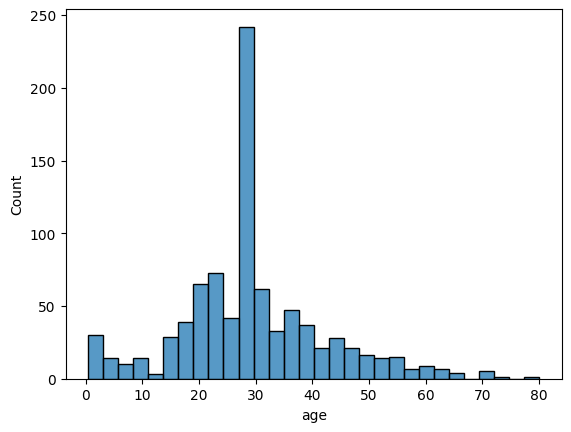

In [19]:
histogram_age=sns.histplot(df,x="age")

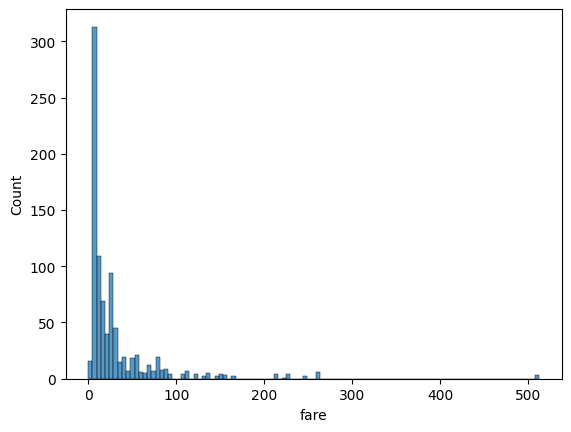

In [20]:

histogram_fare=sns.histplot(df,x="fare")

Age outliers: 65


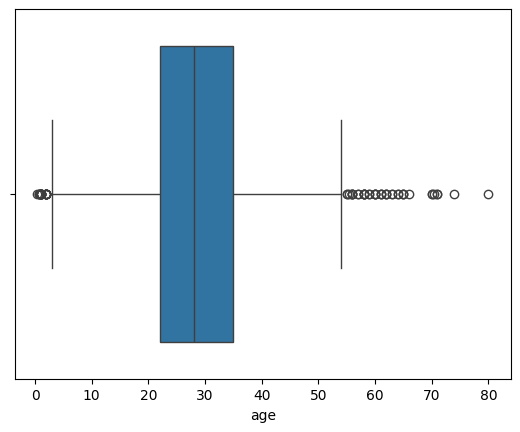

In [21]:
boxplot_age=sns.boxplot(df,x="age")
q1=df['age'].quantile(0.25)
q3=df['age'].quantile(0.75)
iqr=q3-q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

age_outliers=df[(df['age']<lower) | (df['age']>upper)]
print("Age outliers:", age_outliers.shape[0])

Fare outliers: 114


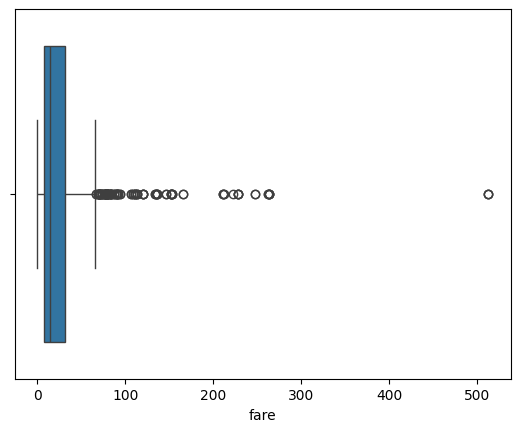

In [22]:
boxplot_fare=sns.boxplot(df,x="fare")
q1=df['fare'].quantile(0.25)
q3=df['fare'].quantile(0.75)
iqr=q3-q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

fare_outliers=df[(df['fare']<lower) | (df['fare']>upper)]
print("Fare outliers:", fare_outliers.shape[0])

In [23]:
fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode()[0]

print("Mean:", fare_mean)
print("Median:", fare_median)
print("Mode:", fare_mode)

Mean: 32.09668087739032
Median: 14.4542
Mode: 8.05


here mean > median > mode hence it is right skewed

In [24]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,28.0,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


In [25]:
female_rate=df[df["sex"] == "female"]["survived"].mean()
male_rate=df[df["sex"] == "male"]["survived"].mean()
pclass1_rate=df[df['pclass'] == 1]["survived"].mean()
pclass2_rate=df[df['pclass'] == 2]["survived"].mean()
pclass3_rate=df[df['pclass'] == 3]["survived"].mean()
female_pclass1_rate=df[(df["sex"] == "female")&(df['pclass'] == 1)]["survived"].mean()
female_pclass2_rate=df[(df["sex"] == "female")&(df['pclass'] == 2)]["survived"].mean()
female_pclass3_rate=df[(df["sex"] == "female")&(df['pclass'] == 3)]["survived"].mean()
male_pclass1_rate=df[(df["sex"] == "male")&(df['pclass'] == 1)]["survived"].mean()
male_pclass2_rate=df[(df["sex"] == "male")&(df['pclass'] == 2)]["survived"].mean()
male_pclass3_rate=df[(df["sex"] == "male")&(df['pclass'] == 3)]["survived"].mean()

print("========== Survival Rate by Sex ==========")
print("Female survival rate:", female_rate)
print("Male survival rate:", male_rate)

print("\n========== Survival Rate by Passenger Class ==========")
print("1st class survival rate:", pclass1_rate)
print("2nd class survival rate:", pclass2_rate)
print("3rd class survival rate:", pclass3_rate)

print("\n========== Survival Rate by Sex and Passenger Class ==========")
print("Female + 1st class survival rate:", female_pclass1_rate)
print("Female + 2nd class survival rate:", female_pclass2_rate)
print("Female + 3rd class survival rate:", female_pclass3_rate)

print("Male + 1st class survival rate:", male_pclass1_rate)
print("Male + 2nd class survival rate:", male_pclass2_rate)
print("Male + 3rd class survival rate:", male_pclass3_rate)

========== Survival Rate by Sex ==========
Female survival rate: 0.7403846153846154
Male survival rate: 0.18890814558058924

========== Survival Rate by Passenger Class ==========
1st class survival rate: 0.6261682242990654
2nd class survival rate: 0.47282608695652173
3rd class survival rate: 0.24236252545824846

========== Survival Rate by Sex and Passenger Class ==========
Female + 1st class survival rate: 0.967391304347826
Female + 2nd class survival rate: 0.9210526315789473
Female + 3rd class survival rate: 0.5
Male + 1st class survival rate: 0.36885245901639346
Male + 2nd class survival rate: 0.1574074074074074
Male + 3rd class survival rate: 0.13544668587896252


for more simple grouping using group by

In [26]:
print("\n========== GroupBy Verification ==========")

print("\nBy Sex:")
print(df.groupby("sex")["survived"].mean())

print("\nBy Passenger Class:")
print(df.groupby("pclass")["survived"].mean())

print("\nBy Sex and Passenger Class:")
print(df.groupby(["sex", "pclass"])["survived"].mean())


========== GroupBy Verification ==========

By Sex:
sex
female    0.740385
male      0.188908
Name: survived, dtype: float64

By Passenger Class:
pclass
1    0.626168
2    0.472826
3    0.242363
Name: survived, dtype: float64

By Sex and Passenger Class:
sex     pclass
female  1         0.967391
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: survived, dtype: float64


In [27]:
corr_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]

corr = df[corr_cols].corr()

print("Correlation Matrix:")
print(corr)

Correlation Matrix:
          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000


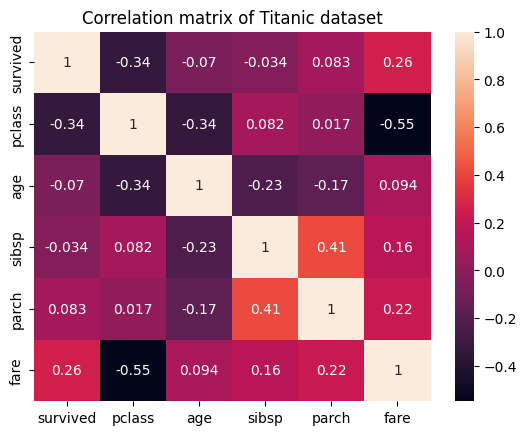

In [28]:
sns.heatmap(corr,annot=True)
plt.title("Correlation matrix of Titanic dataset")
plt.show()

Correlation interpretation: The strongest correlation is between pclass and fare (r = -0.55), indicating a moderate negative relationship.


The second strongest is between sibsp and parch (r = 0.41), indicating a moderate positive relationship.


These correlations describe only patterns not the cause,

# Charts Multivariate "data story"

<Axes: xlabel='age', ylabel='fare'>

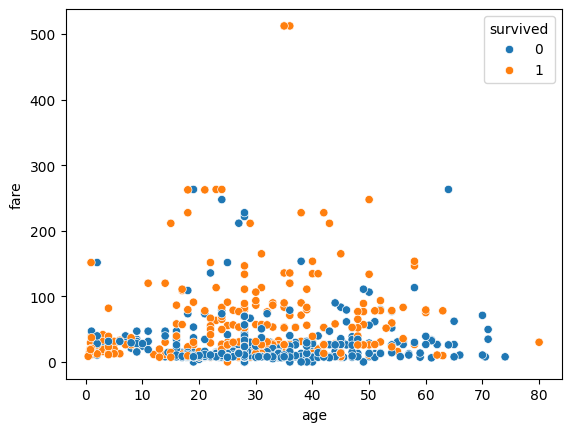

In [29]:
sns.scatterplot(x=df["age"],y=df["fare"],hue=df["survived"])

The scatter plot shows that most passengers paid low fares, with a few passengers paying higher fares. Survivors appear across a wide range of ages and fares, but there are more survivor observations among passengers with higher fares. There is no obvious strong linear relationship between age and fare from the scatter plot alone.

<Axes: xlabel='survived', ylabel='fare'>

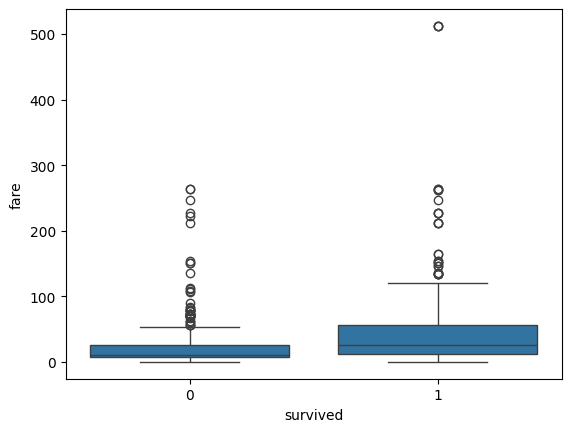

In [30]:
sns.boxplot(x=df["survived"],y=df['fare'])

The boxplot shows that passengers who survived had a higher median fare than passengers who did not survive. The survivor group also has a wider interquartile range, indicating greater variation in fares among survivors. Both groups contain high-fare outliers, including extreme values in the survivor group of 500.

<Axes: xlabel='survived', ylabel='age'>

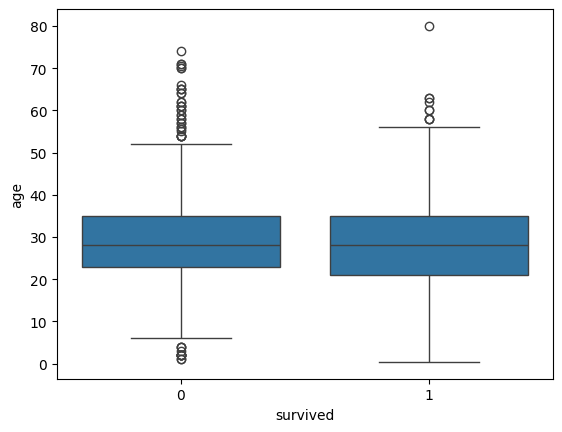

In [31]:
sns.boxplot(x=df["survived"],y=df['age'])

The median age is very similar for passengers who survived and those who did not, with both groups centered around the late twenties. The survivor group has a somewhat wider overall age range, while both groups contain several high-age outliers. Based on this chart alone, age does not show a large difference in the central tendency between the two survival groups.

<Axes: xlabel='pclass', ylabel='survived'>

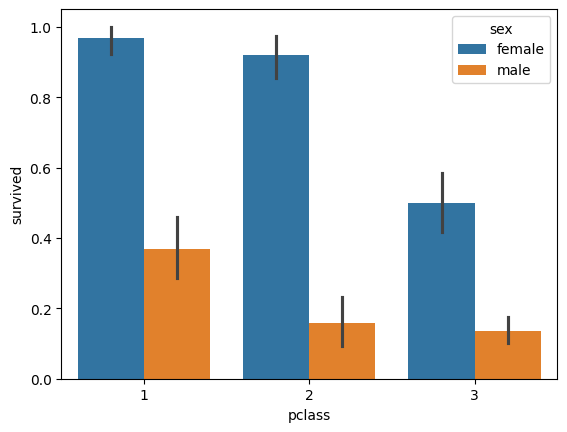

In [32]:
sns.barplot(df,x='pclass',y='survived',hue='sex')

Survival rates differ by both sex and passenger class. Female passengers have higher survival rates than male passengers within each passenger class, while survival rates generally decrease from first class to third class for both genders                                                                                                                                            . The difference between male and female survival rates is particularly pronounced in the second and third classes.

#Regularization

In [33]:
print("Before standardization:")
print("Age - Mean:", df["age"].mean())
print("Age - Std:", df["age"].std())

print("Fare - Mean:", df["fare"].mean())
print("Fare - Std:", df["fare"].std())

Before standardization:
Age - Mean: 29.315151856017994
Age - Std: 12.984932293690774
Fare - Mean: 32.09668087739032
Fare - Std: 49.69750431670801


In [34]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_standardized = df.copy()
df_standardized[["age", "fare"]] = scaler.fit_transform(
    df[["age", "fare"]]
)

In [35]:
print("\nAfter standardization:")
print("Age - Mean:", df_standardized["age"].mean())
print("Age - Std:", df_standardized["age"].std())

print("Fare - Mean:", df_standardized["fare"].mean())
print("Fare - Std:", df_standardized["fare"].std())


After standardization:
Age - Mean: 2.717486278497571e-16
Age - Std: 1.000562904632249
Fare - Mean: 1.3987061727561027e-16
Fare - Std: 1.0005629046322495


In [36]:
print(df_standardized[["age", "fare"]].mean())
print(df_standardized[["age", "fare"]].std(ddof=0))

age     2.717486e-16
fare    1.398706e-16
dtype: float64
age     1.0
fare    1.0
dtype: float64


#Modelling


In [37]:
print(df["survived"].value_counts())
print(df["survived"].value_counts(normalize=True) * 100)

survived
0    549
1    340
Name: count, dtype: int64
survived
0    61.754781
1    38.245219
Name: proportion, dtype: float64


In [38]:
df.columns.tolist()

['survived',
 'pclass',
 'sex',
 'age',
 'sibsp',
 'parch',
 'fare',
 'embarked',
 'class',
 'who',
 'adult_male',
 'embark_town',
 'alive',
 'alone']

Splitting


In [66]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix)
from imblearn.over_sampling import SMOTE

In [41]:
X = df[["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]]
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

#Preprocessing

In [46]:
numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
categorical_features = ["sex", "embarked"]

In [47]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [49]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [50]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

#Training

In [52]:
logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

In [53]:
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [54]:
y_pred_logistic = logistic_pipeline.predict(X_test)

print("Logistic Regression predictions:")
print(y_pred_logistic[:10])

Logistic Regression predictions:
[0 0 0 0 0 1 0 1 1 0]


#Decision Tree

In [55]:
decision_tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42
    ))
])

decision_tree_pipeline.fit(X_train, y_train)

y_pred_tree = decision_tree_pipeline.predict(X_test)

print("Decision Tree predictions:")
print(y_pred_tree[:10])

Decision Tree predictions:
[0 0 0 0 0 1 0 1 1 0]


#Random Farest

In [56]:
random_forest_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42
    ))
])

random_forest_pipeline.fit(X_train, y_train)

y_pred_rf = random_forest_pipeline.predict(X_test)

print("Random Forest predictions:")
print(y_pred_rf[:10])

Random Forest predictions:
[0 0 0 0 0 1 0 1 1 0]


In [58]:
y_prob_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]
y_prob_tree = decision_tree_pipeline.predict_proba(X_test)[:, 1]
y_prob_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]

In [59]:
models = {
    "Logistic Regression": (y_pred_logistic, y_prob_logistic),
    "Decision Tree": (y_pred_tree, y_prob_tree),
    "Random Forest": (y_pred_rf, y_prob_rf)
}

results = []

for model_name, (y_pred, y_prob) in models.items():

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    })

results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.8089887640449438,
  'Precision': 0.7833333333333333,
  'Recall': 0.6911764705882353,
  'F1': 0.734375,
  'AUC': np.float64(0.8609625668449199)},
 {'Model': 'Decision Tree',
  'Accuracy': 0.7696629213483146,
  'Precision': 0.6901408450704225,
  'Recall': 0.7205882352941176,
  'F1': 0.7050359712230215,
  'AUC': np.float64(0.754144385026738)},
 {'Model': 'Random Forest',
  'Accuracy': 0.8202247191011236,
  'Precision': 0.78125,
  'Recall': 0.7352941176470589,
  'F1': 0.7575757575757576,
  'AUC': np.float64(0.8179144385026736)}]

In [60]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.808989,0.783333,0.691176,0.734375,0.860963
1,Decision Tree,0.769663,0.690141,0.720588,0.705036,0.754144
2,Random Forest,0.820225,0.781250,0.735294,0.757576,0.817914


In [61]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)
cm_tree = confusion_matrix(y_test, y_pred_tree)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Logistic Regression:")
print(cm_logistic)

print("\nDecision Tree:")
print(cm_tree)

print("\nRandom Forest:")
print(cm_rf)

Logistic Regression:
[[97 13]
 [21 47]]

Decision Tree:
[[88 22]
 [19 49]]

Random Forest:
[[96 14]
 [18 50]]


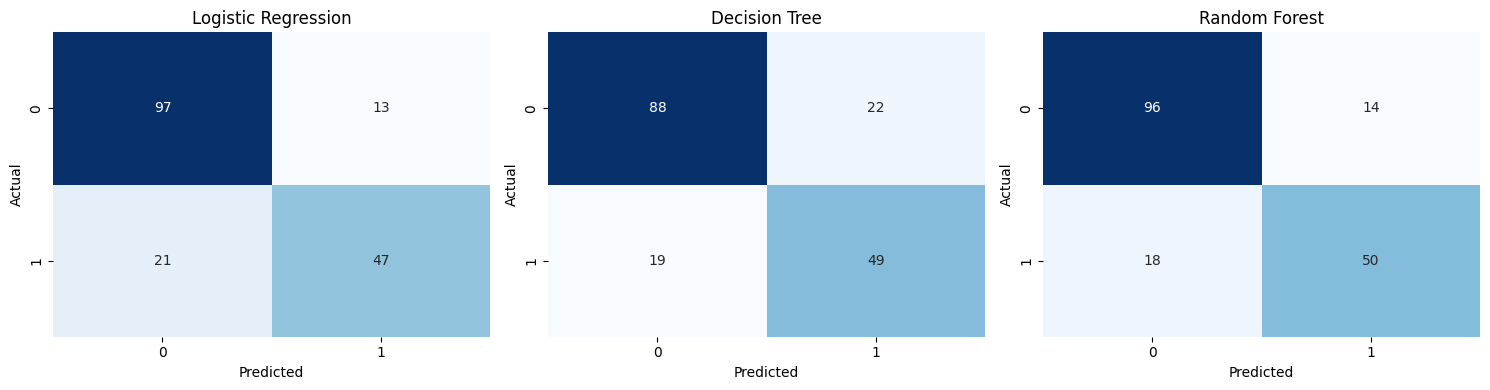

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

confusion_matrices = {
    "Logistic Regression": cm_logistic,
    "Decision Tree": cm_tree,
    "Random Forest": cm_rf
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (model_name, cm) in zip(axes, confusion_matrices.items()):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

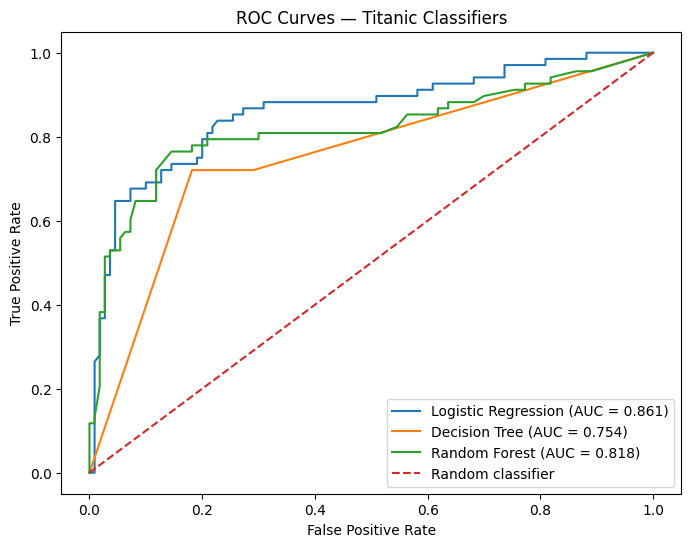

In [63]:
from sklearn.metrics import roc_curve

fpr_logistic, tpr_logistic, _ = roc_curve(y_test, y_prob_logistic)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {results_df.loc[0, 'AUC']:.3f})"
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree (AUC = {results_df.loc[1, 'AUC']:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {results_df.loc[2, 'AUC']:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Titanic Classifiers")
plt.legend()
plt.show()

Random Forest was the best overall winner. It had the highest overall score for getting things right (accuracy), finding hidden patterns (recall), and balancing its mistakes (F1-score).Logistic Regression wasn't far behind. It didn't get as many total answers right, but it was incredibly good at telling the difference between two options (AUC) and was slightly better at avoiding false alarms (precision).Decision Tree came in last place, scoring lower than the other two models across almost every test.

In [64]:
baseline_precision = precision_score(y_test, y_pred_rf)
baseline_recall = recall_score(y_test, y_pred_rf)
baseline_f1 = f1_score(y_test, y_pred_rf)

print("Baseline Random Forest")
print("Precision:", baseline_precision)
print("Recall:", baseline_recall)
print("F1:", baseline_f1)

Baseline Random Forest
Precision: 0.78125
Recall: 0.7352941176470589
F1: 0.7575757575757576


In [65]:
balanced_rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

balanced_rf_pipeline.fit(X_train, y_train)

y_pred_balanced = balanced_rf_pipeline.predict(X_test)

balanced_precision = precision_score(y_test, y_pred_balanced)
balanced_recall = recall_score(y_test, y_pred_balanced)
balanced_f1 = f1_score(y_test, y_pred_balanced)

print("Balanced Random Forest")
print("Precision:", balanced_precision)
print("Recall:", balanced_recall)
print("F1:", balanced_f1)

Balanced Random Forest
Precision: 0.7692307692307693
Recall: 0.7352941176470589
F1: 0.7518796992481203


In [67]:
# Fit preprocessing only on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
survived
0    439
1    272
Name: count, dtype: int64

After SMOTE:
survived
1    439
0    439
Name: count, dtype: int64


In [68]:
smote_rf = RandomForestClassifier(
    random_state=42
)

smote_rf.fit(X_train_smote, y_train_smote)

y_pred_smote = smote_rf.predict(X_test_processed)

In [69]:
smote_precision = precision_score(y_test, y_pred_smote)
smote_recall = recall_score(y_test, y_pred_smote)
smote_f1 = f1_score(y_test, y_pred_smote)

print("SMOTE Random Forest")
print("Precision:", smote_precision)
print("Recall:", smote_recall)
print("F1:", smote_f1)

SMOTE Random Forest
Precision: 0.746031746031746
Recall: 0.6911764705882353
F1: 0.7175572519083969


When training our AI model, we noticed the data was uneven: 62% of the people did not survive, while only 38% did. Because the AI had less survivor data to learn from, we tested two popular "balancing tricks" to help it out. However, both tricks actually backfired. The simple baseline strategy (doing nothing extra) outperformed the others, proving that forcing the data to be balanced isn't always the best move.

In [70]:
rf_tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        oob_score=True,
        random_state=42
    ))
])

In [71]:
param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 5, 10, 15],
    "classifier__max_features": ["sqrt", "log2"]
}

In [72]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=rf_tuning_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    refit=True
)

In [73]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['pclass',
                                                                          'age',
                                                                          'sibsp',
                                                                          'parch',
                                                                          'fare']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['sex',
                                                                          'embarked'])])),
                                       ('classifier',
                                        RandomForestClassifier(oob_score=True,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [None, 5, 10, 15],
                         'classifier__max_features': ['sqrt', 'log2'],
                         'classifier__n_estimators': [100, 200, 300]},
             scoring='f1')

In [74]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1:")
print(grid_search.best_score_)

Best Parameters:
{'classifier__max_depth': 15, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 200}

Best Cross-Validation F1:
0.7471342909500108


In [75]:
best_rf_pipeline = grid_search.best_estimator_

oob_score = best_rf_pipeline.named_steps["classifier"].oob_score_

print("\nOOB Score:")
print(oob_score)


OOB Score:
0.8073136427566807


In [76]:
y_pred_tuned_rf = best_rf_pipeline.predict(X_test)
y_prob_tuned_rf = best_rf_pipeline.predict_proba(X_test)[:, 1]

print("Tuned Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned_rf))
print("Precision:", precision_score(y_test, y_pred_tuned_rf))
print("Recall:", recall_score(y_test, y_pred_tuned_rf))
print("F1:", f1_score(y_test, y_pred_tuned_rf))
print("AUC:", roc_auc_score(y_test, y_prob_tuned_rf))

Tuned Random Forest
Accuracy: 0.8146067415730337
Precision: 0.7868852459016393
Recall: 0.7058823529411765
F1: 0.7441860465116279
AUC: 0.8196524064171123


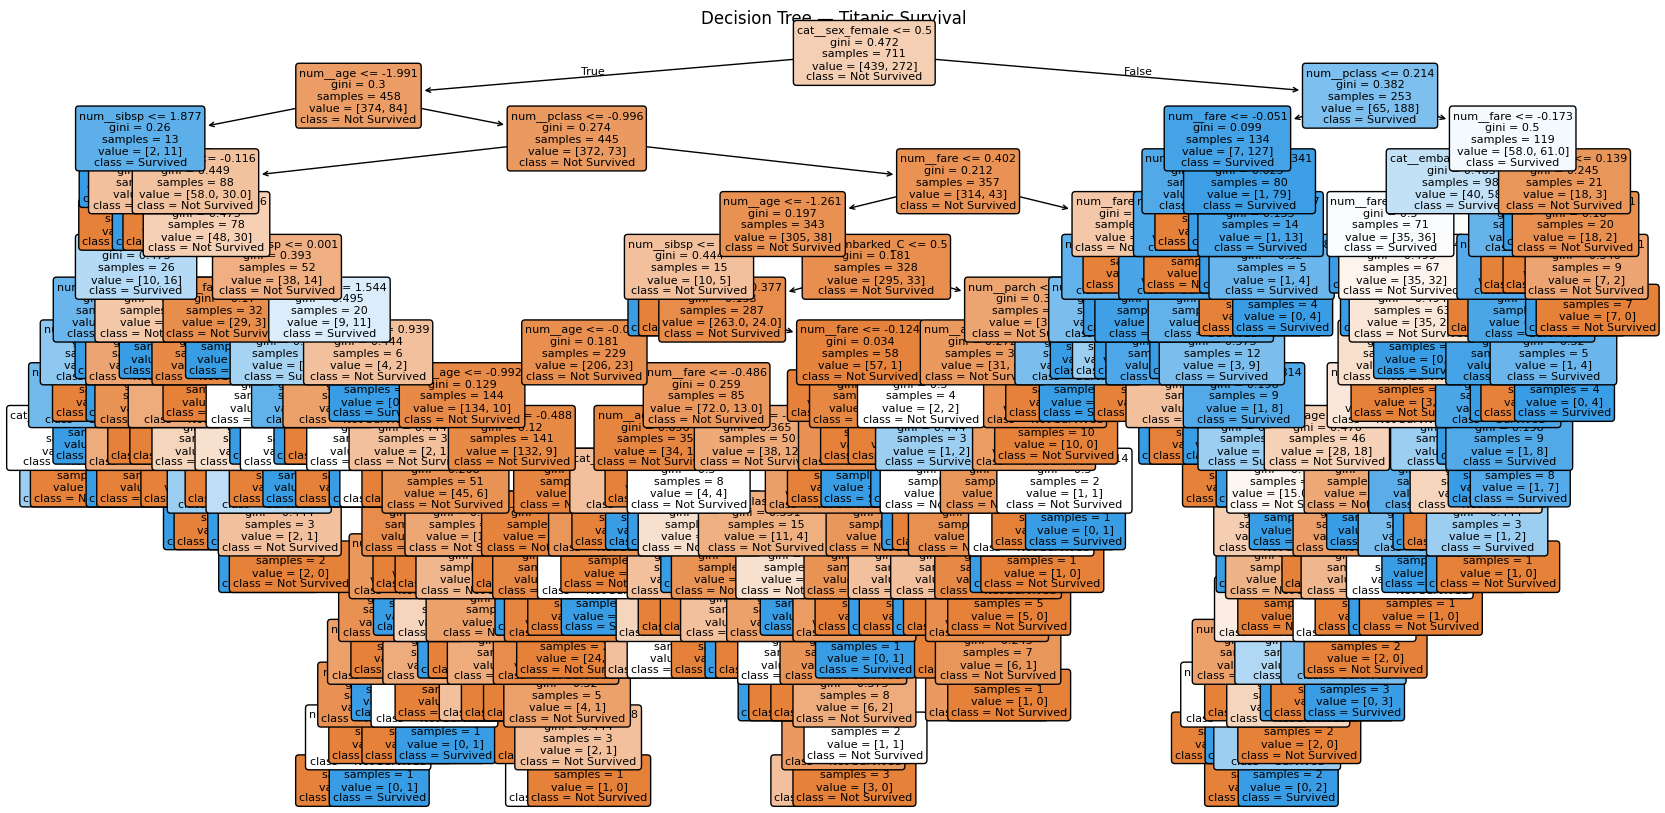

In [77]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree_model = decision_tree_pipeline.named_steps["classifier"]
tree_preprocessor = decision_tree_pipeline.named_steps["preprocessor"]

feature_names = tree_preprocessor.get_feature_names_out()

plt.figure(figsize=(20, 10))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree — Titanic Survival")
plt.show()

In [78]:
X_reg = df[["pclass","sex","age","sibsp","parch","embarked"]]

y_reg = df["fare"]

print("X_reg shape:", X_reg.shape)
print("y_reg shape:", y_reg.shape)

X_reg shape: (889, 6)
y_reg shape: (889,)


In [79]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg,test_size=0.2,random_state=42)

print("X_reg_train:", X_reg_train.shape)
print("X_reg_test:", X_reg_test.shape)

X_reg_train: (711, 6)
X_reg_test: (178, 6)


In [80]:
reg_numeric_features = ["pclass","age","sibsp","parch"]

reg_categorical_features = ["sex","embarked"]

In [81]:
reg_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

reg_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [82]:
reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", reg_numeric_transformer, reg_numeric_features),
        ("cat", reg_categorical_transformer, reg_categorical_features)
    ]
)

In [83]:
from sklearn.linear_model import LinearRegression
regression_pipeline = Pipeline(steps=[
    ("preprocessor", reg_preprocessor),
    ("regressor", LinearRegression())
])

In [84]:
regression_pipeline.fit(X_reg_train, y_reg_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked'])])),
                ('regressor', LinearRegression())])

In [85]:
y_reg_pred = regression_pipeline.predict(X_reg_test)

In [86]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_reg_test, y_reg_pred)

rmse = np.sqrt(
    mean_squared_error(y_reg_test, y_reg_pred)
)

r2 = r2_score(y_reg_test, y_reg_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 21.138552296883095
RMSE: 41.746502315739114
R²: 0.34677389181134044


In [87]:
X_reg_test_transformed = regression_pipeline.named_steps[
    "preprocessor"
].transform(X_reg_test)

n = X_reg_test_transformed.shape[0]
p = X_reg_test_transformed.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("Number of observations (n):", n)
print("Number of predictors after preprocessing (p):", p)
print("Adjusted R²:", adjusted_r2)

Number of observations (n): 178
Number of predictors after preprocessing (p): 9
Adjusted R²: 0.3117796360155194


In [88]:
residuals = y_reg_test - y_reg_pred

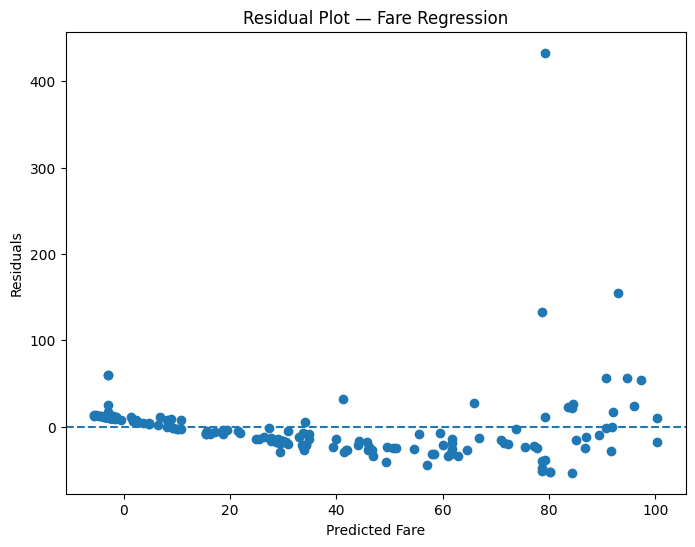

In [89]:
plt.figure(figsize=(8, 6))

plt.scatter(y_reg_pred, residuals)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot — Fare Regression")

plt.show()

#Model Comparision

In [90]:
classification_comparison = results_df.copy()

classification_comparison

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.808989,0.783333,0.691176,0.734375,0.860963
1,Decision Tree,0.769663,0.690141,0.720588,0.705036,0.754144
2,Random Forest,0.820225,0.781250,0.735294,0.757576,0.817914


In [91]:
regression_comparison = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R²": [r2],
    "Adjusted R²": [adjusted_r2]
})

regression_comparison

,Model,MAE,RMSE,R²,Adjusted R²
0,Linear Regression,21.138552,41.746502,0.346774,0.31178


I recommend using the baseline Random Forest model for this project. Out of the three main options tested, it won the top spot for overall accuracy and gave the best balance of right answers. While Logistic Regression is a strong runner-up if you need to rank predictions by probability, the Decision Tree came in last place with the weakest scores. Separately, our price/number predicting model achieved an R² score of 0.35, though its errors are a bit inconsistent and need caution.

#Saving model

In [92]:
import joblib

joblib.dump(
    random_forest_pipeline,
    "best_titanic_classifier.joblib"
)

print("Pipeline saved successfully.")

Pipeline saved successfully.


In [93]:
loaded_pipeline = joblib.load(
    "best_titanic_classifier.joblib"
)

print("Pipeline reloaded successfully.")

Pipeline reloaded successfully.


In [94]:
loaded_predictions = loaded_pipeline.predict(X_test)

print("First 10 predictions from reloaded pipeline:")
print(loaded_predictions[:10])

print("\nOriginal predictions:")
print(y_pred_rf[:10])

print(
    "\nPredictions identical:",
    np.array_equal(loaded_predictions, y_pred_rf)
)

First 10 predictions from reloaded pipeline:
[0 0 0 0 0 1 0 1 1 0]

Original predictions:
[0 0 0 0 0 1 0 1 1 0]

Predictions identical: True
